# 06 — Sentiment-Based Backtesting Pipeline

End-to-end replication and extension of `backtesting_pipeline_fixed.py` — adapted for the full 3-source corpus.  

**Pipeline**
1. Load merged news corpus + cached prices  
2. Generate sentiment predictions via trained ensemble (→ FinBERT fallback)  
3. Simulate trades with `SentimentBacktester`  
4. Analyse results with `BacktestAnalyzer`  
5. Produce charts and CSV report  

**Strategy**  
- Buy on `UP` signal with confidence ≥ threshold  
- Sell on `DOWN` signal or after N-day holding period  
- Position sizing proportional to confidence  
- 0.1% commission each side  

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pickle, warnings
from pathlib import Path
from datetime import datetime, timedelta
from tqdm.notebook import tqdm
from typing import Dict, List, Optional

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_palette('husl')

ROOT    = Path('..')
PROC    = ROOT / 'data' / 'processed'
MODELS  = ROOT / 'models' / 'saved_models'
REPORTS = ROOT / 'results' / 'reports'
PLOTS   = ROOT / 'results' / 'plots'
REPORTS.mkdir(parents=True, exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)

TICKER_MAP = {
    'HDFCBANK'  : 'HDFCBANK.NS',
    'ICICIBANK' : 'ICICIBANK.NS',
    'SBIN'      : 'SBIN.NS',
    'AXISBANK'  : 'AXISBANK.NS',
    'KOTAKBANK' : 'KOTAKBANK.NS',
    'INDUSINDBK': 'INDUSINDBK.NS',
}

print('✅ Imports OK')

✅ Imports OK


## 1. Load data

In [3]:
all_news = pd.read_csv(PROC / 'all_banking_news.csv', parse_dates=['date'])
all_news['date'] = pd.to_datetime(all_news['date']).dt.normalize()

# ── configurable sample size ──
SAMPLE_SIZE = min(500, len(all_news))
news_data   = all_news.sample(n=SAMPLE_SIZE, random_state=42).sort_values('date').reset_index(drop=True)

print(f'Using {len(news_data):,} articles  |  '
      f'{news_data.date.min().date()} → {news_data.date.max().date()}')
news_data[['ticker','date','source','headline']].head(5)

Using 500 articles  |  2022-03-01 → 2026-03-24


,ticker,date,source,headline
0,SBIN,2022-03-01,moneycontrol,Buy State Bank of India; target of Rs 610: Pra...
1,ICICIBANK,2022-07-08,moneycontrol,Markets extend rally to 3rd day; Sensex climbs...
2,ICICIBANK,2022-08-05,moneycontrol,"ICICI Bank, PNB hike external benchmark based ..."
3,SBIN,2022-08-06,moneycontrol,"SBI Q1 result | Net profit of Rs 6,068 crore, ..."
4,ICICIBANK,2022-10-25,moneycontrol,ICICI Bank Q2 earnings: Can it trade at a valu...


## 2. Fetch / load stock prices

In [4]:
# Try loading the price cache from feature engineering
cache_path = PROC / 'price_cache.pkl'

if cache_path.exists():
    with open(cache_path, 'rb') as f:
        price_data = pickle.load(f)
    print(f'Loaded price cache for: {list(price_data.keys())}')
else:
    print('Price cache not found — fetching fresh from Yahoo Finance...')
    price_data = {}
    start = (news_data['date'].min() - pd.Timedelta(days=30)).strftime('%Y-%m-%d')
    end   = (news_data['date'].max() + pd.Timedelta(days=30)).strftime('%Y-%m-%d')

    for tk, yf_sym in tqdm(TICKER_MAP.items(), desc='Fetching'):
        try:
            hist = yf.Ticker(yf_sym).history(start=start, end=end)
            if not hist.empty:
                hist = hist.reset_index()
                hist['Date'] = pd.to_datetime(hist['Date']).dt.tz_localize(None).dt.normalize()
                hist['ticker'] = tk
                price_data[tk] = hist
        except Exception as e:
            print(f'  {tk}: {e}')

    with open(cache_path, 'wb') as f:
        pickle.dump(price_data, f)
    print(f'Fetched and cached prices for {len(price_data)} tickers')

Loaded price cache for: ['HDFCBANK', 'ICICIBANK', 'SBIN', 'AXISBANK', 'KOTAKBANK', 'INDUSINDBK']


## 3. Generate predictions

In [5]:
USE_TRAINED = False

# ── Try trained ensemble ──
try:
    import sys
    sys.path.insert(0, str(ROOT / 'notebooks'))
    import importlib.util, types

    # Load predictor class from notebook 05 as a module
    spec   = importlib.util.spec_from_file_location('pred05', ROOT / 'notebooks' / '05_prediction_pipeline.ipynb')

    # Alternative: just reconstruct the class inline (safer)
    import pickle as _pkl
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    import scipy.sparse as sp

    with open(MODELS / 'ensemble_stock_predictor.pkl', 'rb') as f:
        _b = _pkl.load(f)

    class _Predictor:
        BANKING_BOOSTS = {
            'npa': -1.5, 'fraud': -2.0, 'default': -1.5, 'downgrade': -1.8,
            'stressed': -1.2, 'recovery': +1.5, 'profit': +1.8, 'dividend': +1.5,
            'acquisition': +0.8, 'merger': +0.8, 'rally': +1.5, 'surge': +1.5,
            'crash': -2.0, 'collapse': -2.0, 'penalty': -1.5, 'fine': -1.0,
            'upgrade': +1.5, 'growth': +1.2, 'record': +1.0
        }
        def __init__(self, b):
            self.__dict__.update(b)
            self.sia = SentimentIntensityAnalyzer()
            self.sia.lexicon.update(self.BANKING_BOOSTS)
        def predict(self, headline, date_str, ticker=None, body='', verbose=False):
            date = pd.to_datetime(date_str)
            vs   = self.sia.polarity_scores(headline)
            text = (headline + ' ' + body).strip()[:1500]
            row_dict = {
                'combined_text_512': text, 'headline_len': len(headline.split()),
                'vader_pos': vs['pos'], 'vader_neg': vs['neg'],
                'vader_neu': vs['neu'], 'vader_compound': vs['compound'],
                'day_of_week': date.dayofweek, 'month': date.month,
                'quarter': date.quarter, 'is_monday': int(date.dayofweek==0),
                'is_friday': int(date.dayofweek==4),
                'is_month_end': int(date.is_month_end),
                'is_qtr_end': int(date.is_quarter_end),
            }
            X_tf = self.tfidf.transform([text])
            X_tb = self.scaler.transform(pd.DataFrame([row_dict])[self.tabular_cols].values)
            X    = sp.hstack([X_tf, sp.csr_matrix(X_tb)])
            meta = np.hstack([self.rf.predict_proba(X), self.gb.predict_proba(X.toarray())])
            proba = self.meta_lr.predict_proba(meta)[0]
            idx   = proba.argmax()
            return {'predicted_movement': self.le.classes_[idx], 'confidence': float(proba[idx])}

    predictor    = _Predictor(_b)
    USE_TRAINED  = True
    print('✅ Trained ensemble loaded')
except Exception as e:
    print(f'⚠️  Trained model unavailable ({e}). Falling back to FinBERT...')

✅ Trained ensemble loaded


In [6]:
if not USE_TRAINED:
    try:
        from transformers import pipeline as hf_pipeline
        finbert = hf_pipeline('sentiment-analysis', model='ProsusAI/finbert')
        LABEL_MAP = {'positive': 'UP', 'negative': 'DOWN', 'neutral': 'NEUTRAL'}

        class _FinBERTPredictor:
            def predict(self, headline, date_str, ticker=None, body='', verbose=False):
                r = finbert(headline[:512])[0]
                return {'predicted_movement': LABEL_MAP.get(r['label'], 'NEUTRAL'),
                        'confidence': float(r['score'])}

        predictor   = _FinBERTPredictor()
        USE_TRAINED = True
        print('✅ FinBERT loaded')
    except Exception as e:
        print(f'⚠️  FinBERT failed ({e}). Using VADER-only fallback.')
        from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
        _sia = SentimentIntensityAnalyzer()

        class _VADERPredictor:
            def predict(self, headline, date_str, ticker=None, body='', verbose=False):
                c = _sia.polarity_scores(headline)['compound']
                if c > 0.05:  return {'predicted_movement': 'UP',      'confidence': min(0.5 + c/2, 0.95)}
                if c < -0.05: return {'predicted_movement': 'DOWN',    'confidence': min(0.5 - c/2, 0.95)}
                return         {'predicted_movement': 'NEUTRAL',  'confidence': 0.5}

        predictor = _VADERPredictor()
        print('✅ VADER fallback active')

In [7]:
batch_preds = []
for _, row in tqdm(news_data.iterrows(), total=len(news_data), desc='Predicting'):
    try:
        r = predictor.predict(
            str(row.get('headline', '')),
            str(row['date']),
            ticker=row.get('ticker'),
            body=str(row.get('text', ''))
        )
    except Exception:
        r = {'predicted_movement': 'NEUTRAL', 'confidence': 0.33}
    batch_preds.append(r)

predictions = pd.DataFrame(batch_preds)
predictions['index'] = range(len(predictions))

print('\nPrediction distribution:')
print(predictions['predicted_movement'].value_counts())
print(f'Mean confidence: {predictions["confidence"].mean():.3f}')

Predicting:   0%|          | 0/500 [00:00<?, ?it/s]


Prediction distribution:
predicted_movement
UP         252
DOWN       198
NEUTRAL     50
Name: count, dtype: int64
Mean confidence: 0.498


## 4. Backtesting engine

In [10]:
class SentimentBacktester:
    """Simulates a sentiment-driven long-only portfolio."""

    def __init__(self, initial_capital=1_000_000, commission_pct=0.001):
        self.initial_capital = initial_capital
        self.commission_pct  = commission_pct
        self.reset()

    def reset(self):
        self.cash     = self.initial_capital
        self.holdings = {}   # ticker → shares
        self.trades   = []

    # ── helpers ───────────────────────────────────────────────────
    def _get_price(self, ticker, from_date, next_day=True):
        if ticker not in price_data: return None
        df  = price_data[ticker]
        col = 'Date' if 'Date' in df.columns else 'date'
        dates = df[col]
        if next_day:
            fut = df[dates > from_date].sort_values(col)
        else:
            fut = df[dates >= from_date].sort_values(col)
        return float(fut.iloc[0]['Close']) if not fut.empty else None

    def _get_price_near(self, ticker, target):
        if ticker not in price_data: return None
        df  = price_data[ticker]
        col = 'Date' if 'Date' in df.columns else 'date'
        exact = df[df[col] == target]
        if not exact.empty: return float(exact.iloc[0]['Close'])
        fut = df[df[col] > target].sort_values(col)
        if not fut.empty and (fut.iloc[0][col] - target).days <= 5:
            return float(fut.iloc[0]['Close'])
        return None

    def _portfolio_value(self, current_prices):
        hv = sum(sh * current_prices.get(tk, 0) for tk, sh in self.holdings.items())
        return self.cash + hv

    def _current_prices(self, date):
        return {tk: p for tk in self.holdings
                if (p := self._get_price_near(tk, date)) is not None}

    # ── trade execution ───────────────────────────────────────────
    def _buy(self, ticker, price, date, confidence):
        max_shares = int((self.cash * min(confidence, 0.25)) / price)
        if max_shares < 1: return False
        cost  = max_shares * price * (1 + self.commission_pct)
        if cost > self.cash: return False
        self.cash -= cost
        self.holdings[ticker] = self.holdings.get(ticker, 0) + max_shares
        self.trades.append(dict(date=date, ticker=ticker, action='BUY',
                                price=price, shares=max_shares,
                                value=max_shares*price, confidence=confidence))
        return True

    def _sell(self, ticker, price, date, confidence):
        shares = self.holdings.get(ticker, 0)
        if shares < 1: return False
        revenue = shares * price * (1 - self.commission_pct)
        self.cash += revenue
        del self.holdings[ticker]
        self.trades.append(dict(date=date, ticker=ticker, action='SELL',
                                price=price, shares=shares,
                                value=shares*price, confidence=confidence))
        return True

    # ── main loop ─────────────────────────────────────────────────
    def run(self, news_df, preds_df, confidence_threshold=0.60,
            holding_period=5) -> Dict:
        self.reset()
        combined = news_df.copy().reset_index(drop=True)
        combined = combined.join(preds_df[['predicted_movement','confidence']],
                                  how='left')

        open_positions = []   # list of dicts: ticker, entry_date, exit_date, confidence
        daily_values   = []
        portfolio_value = self.initial_capital

        for _, row in tqdm(combined.iterrows(), total=len(combined), desc='Backtesting'):
            date   = pd.to_datetime(row['date']).normalize()
            ticker = row['ticker']
            pred   = row.get('predicted_movement', 'NEUTRAL')
            conf   = float(row.get('confidence', 0.5))

            if conf < confidence_threshold:
                continue

            exec_price = self._get_price(ticker, date, next_day=True)
            if exec_price is None:
                continue

            if pred == 'UP':
                if self._buy(ticker, exec_price, date, conf):
                    open_positions.append({
                        'ticker': ticker, 'entry_date': date, 'confidence': conf,
                        'exit_date': date + pd.Timedelta(days=holding_period)
                    })
            elif pred == 'DOWN':
                self._sell(ticker, exec_price, date, conf)

            # Close expired positions
            still_open = []
            for pos in open_positions:
                if pos['exit_date'] <= date:
                    exit_price = self._get_price_near(pos['ticker'], pos['exit_date'])
                    if exit_price:
                        self._sell(pos['ticker'], exit_price, pos['exit_date'], pos['confidence'])
                else:
                    still_open.append(pos)
            open_positions = still_open

            cur_prices      = self._current_prices(date)
            portfolio_value = self._portfolio_value(cur_prices)
            daily_values.append({'date': date, 'portfolio_value': portfolio_value,
                                  'cash': self.cash,
                                  'holdings_value': portfolio_value - self.cash})

        return {
            'trades'               : self.trades,
            'final_portfolio_value': portfolio_value,
            'daily_values'         : daily_values,
            'num_trades'           : len(self.trades),
            'final_cash'           : self.cash,
            'final_holdings'       : dict(self.holdings),
        }

print('SentimentBacktester defined.')

SentimentBacktester defined.


## 5. Run backtest

In [16]:
# ── tunable parameters ──
INITIAL_CAPITAL      = 1_000_000   # INR 10 lakh
CONFIDENCE_THRESHOLD = 0.70
HOLDING_PERIOD       = 5           # trading days
COMMISSION           = 0.001       # 0.1%

# Normalize cached price frames so backtester can always find a date column
for tk, df in list(price_data.items()):
    if 'Date' not in df.columns and 'date' not in df.columns:
        if isinstance(df.index, pd.DatetimeIndex):
            idx_name = df.index.name if df.index.name is not None else 'index'
            df = df.reset_index().rename(columns={idx_name: 'Date'})
        else:
            df = df.reset_index().rename(columns={'index': 'Date'})

    date_col = 'Date' if 'Date' in df.columns else 'date'
    df[date_col] = pd.to_datetime(df[date_col], utc=True).dt.tz_convert(None).dt.normalize()
    price_data[tk] = df

backtester = SentimentBacktester(initial_capital=INITIAL_CAPITAL,
                                  commission_pct=COMMISSION)

results = backtester.run(
    news_df=news_data,
    preds_df=predictions,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    holding_period=HOLDING_PERIOD
)

total_return = (results['final_portfolio_value'] - INITIAL_CAPITAL) / INITIAL_CAPITAL
print('\n' + '=' * 50)
print(f'  Initial Capital : ₹{INITIAL_CAPITAL:>12,.0f}')
print(f'  Final Value     : ₹{results["final_portfolio_value"]:>12,.0f}')
print(f'  Total Return    : {total_return:>11.2%}')
print(f'  Trades Executed : {results["num_trades"]:>12,}')
print('=' * 50)

Backtesting:   0%|          | 0/500 [00:00<?, ?it/s]


  Initial Capital : ₹   1,000,000
  Final Value     : ₹   1,009,568
  Total Return    :       0.96%
  Trades Executed :           26


## 6. Performance analysis

In [17]:
class BacktestAnalyzer:
    """Computes risk metrics and generates report charts."""

    def __init__(self, results, initial_capital):
        self.results         = results
        self.initial_capital = initial_capital
        self.trades_df       = pd.DataFrame(results['trades']) if results['trades'] else pd.DataFrame()
        self.daily_df        = pd.DataFrame(results['daily_values']) if results['daily_values'] else pd.DataFrame()

    def metrics(self) -> dict:
        m  = {}
        fv = self.results['final_portfolio_value']
        m['total_return'] = (fv - self.initial_capital) / self.initial_capital

        if self.daily_df.empty or len(self.daily_df) < 3:
            m.update({'volatility':0,'sharpe':0,'max_drawdown':0,'win_rate':0.0})
            return m

        self.daily_df['daily_ret'] = self.daily_df['portfolio_value'].pct_change()
        rets = self.daily_df['daily_ret'].dropna()
        ann_vol  = rets.std() * np.sqrt(252)
        ann_ret  = rets.mean() * 252
        m['volatility']   = ann_vol
        m['sharpe']       = ann_ret / ann_vol if ann_vol > 0 else 0
        cumret = (1 + rets).cumprod()
        m['max_drawdown'] = ((cumret - cumret.expanding().max()) / cumret.expanding().max()).min()
        m['win_rate']     = self._win_rate()
        m['total_trades'] = len(self.trades_df)
        if not self.trades_df.empty and 'action' in self.trades_df.columns:
            m['buy_trades']  = (self.trades_df['action'] == 'BUY').sum()
            m['sell_trades'] = (self.trades_df['action'] == 'SELL').sum()
        return m

    def _win_rate(self):
        if self.trades_df.empty: return 0.0
        buys  = self.trades_df[self.trades_df['action'] == 'BUY']
        sells = self.trades_df[self.trades_df['action'] == 'SELL']
        if buys.empty or sells.empty: return 0.0
        wins, total = 0, 0
        for _, b in buys.iterrows():
            s_match = sells[(sells['ticker'] == b['ticker']) & (sells['date'] > b['date'])]
            if not s_match.empty:
                if (s_match.iloc[0]['price'] - b['price']) > 0: wins += 1
                total += 1
        return wins / total if total else 0.0

    def print_report(self):
        m = self.metrics()
        fv = self.results['final_portfolio_value']
        print('\n' + '='*60)
        print('  BACKTEST REPORT')
        print('='*60)
        print(f'  Initial Capital : ₹{self.initial_capital:>12,.0f}')
        print(f'  Final Value     : ₹{fv:>12,.0f}')
        print(f'  Total Return    : {m["total_return"]:>11.2%}')
        print(f'  Annualised Vol  : {m["volatility"]:>11.2%}')
        print(f'  Sharpe Ratio    : {m["sharpe"]:>11.2f}')
        print(f'  Max Drawdown    : {m["max_drawdown"]:>11.2%}')
        print(f'  Win Rate        : {m["win_rate"]:>11.1%}')
        print(f'  Total Trades    : {m.get("total_trades",0):>12,}')
        print(f'  Cash Remaining  : ₹{self.results["final_cash"]:>12,.0f}')
        print(f'  Open Positions  : {len(self.results["final_holdings"]):>12}')
        print('='*60)

    def plot_equity_curve(self, save=True):
        if self.daily_df.empty:
            print('No daily data to plot.'); return
        fig, axes = plt.subplots(2, 2, figsize=(15, 9))

        # Equity curve
        ax = axes[0, 0]
        self.daily_df.set_index('date')['portfolio_value'].plot(ax=ax, color='royalblue', lw=1.5)
        ax.axhline(self.initial_capital, color='grey', ls='--', lw=0.8, label='Benchmark')
        ax.set_title('Portfolio Equity Curve'); ax.set_ylabel('₹ Value')
        ax.legend(); ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

        # Cash vs holdings
        ax = axes[0, 1]
        ddf = self.daily_df.set_index('date')
        ddf[['cash','holdings_value']].plot.area(ax=ax, stacked=True, alpha=0.7)
        ax.set_title('Cash vs Holdings'); ax.set_ylabel('₹')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

        # Drawdown
        ax = axes[1, 0]
        rets = ddf['portfolio_value'].pct_change().dropna()
        cum  = (1 + rets).cumprod()
        dd   = (cum - cum.expanding().max()) / cum.expanding().max()
        dd.plot(ax=ax, color='crimson', lw=1.2, label='Drawdown')
        ax.fill_between(dd.index, dd, 0, alpha=0.3, color='crimson')
        ax.set_title('Drawdown'); ax.set_ylabel('%')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

        # Trade actions per ticker
        ax = axes[1, 1]
        if not self.trades_df.empty and 'ticker' in self.trades_df.columns:
            tc = self.trades_df.groupby(['ticker','action']).size().unstack(fill_value=0)
            tc.plot(kind='bar', ax=ax, color=['coral','steelblue'])
            ax.set_title('Trades per Ticker'); ax.set_xlabel('')
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
        else:
            ax.text(0.5, 0.5, 'No trades', ha='center', va='center', transform=ax.transAxes)

        plt.suptitle('Sentiment Backtesting Dashboard', fontsize=14, fontweight='bold')
        plt.tight_layout()
        if save:
            plt.savefig(PLOTS / 'backtest_dashboard.png', dpi=150, bbox_inches='tight')
            print(f'Saved → {PLOTS}/backtest_dashboard.png')
        plt.show()

print('BacktestAnalyzer defined.')

BacktestAnalyzer defined.



  BACKTEST REPORT
  Initial Capital : ₹   1,000,000
  Final Value     : ₹     985,739
  Total Return    :      -1.43%
  Annualised Vol  :       6.73%
  Sharpe Ratio    :       -0.48
  Max Drawdown    :      -2.09%
  Win Rate        :       53.6%
  Total Trades    :           52
  Cash Remaining  : ₹     985,739
  Open Positions  :            0
Saved → ..\results\plots/backtest_dashboard.png


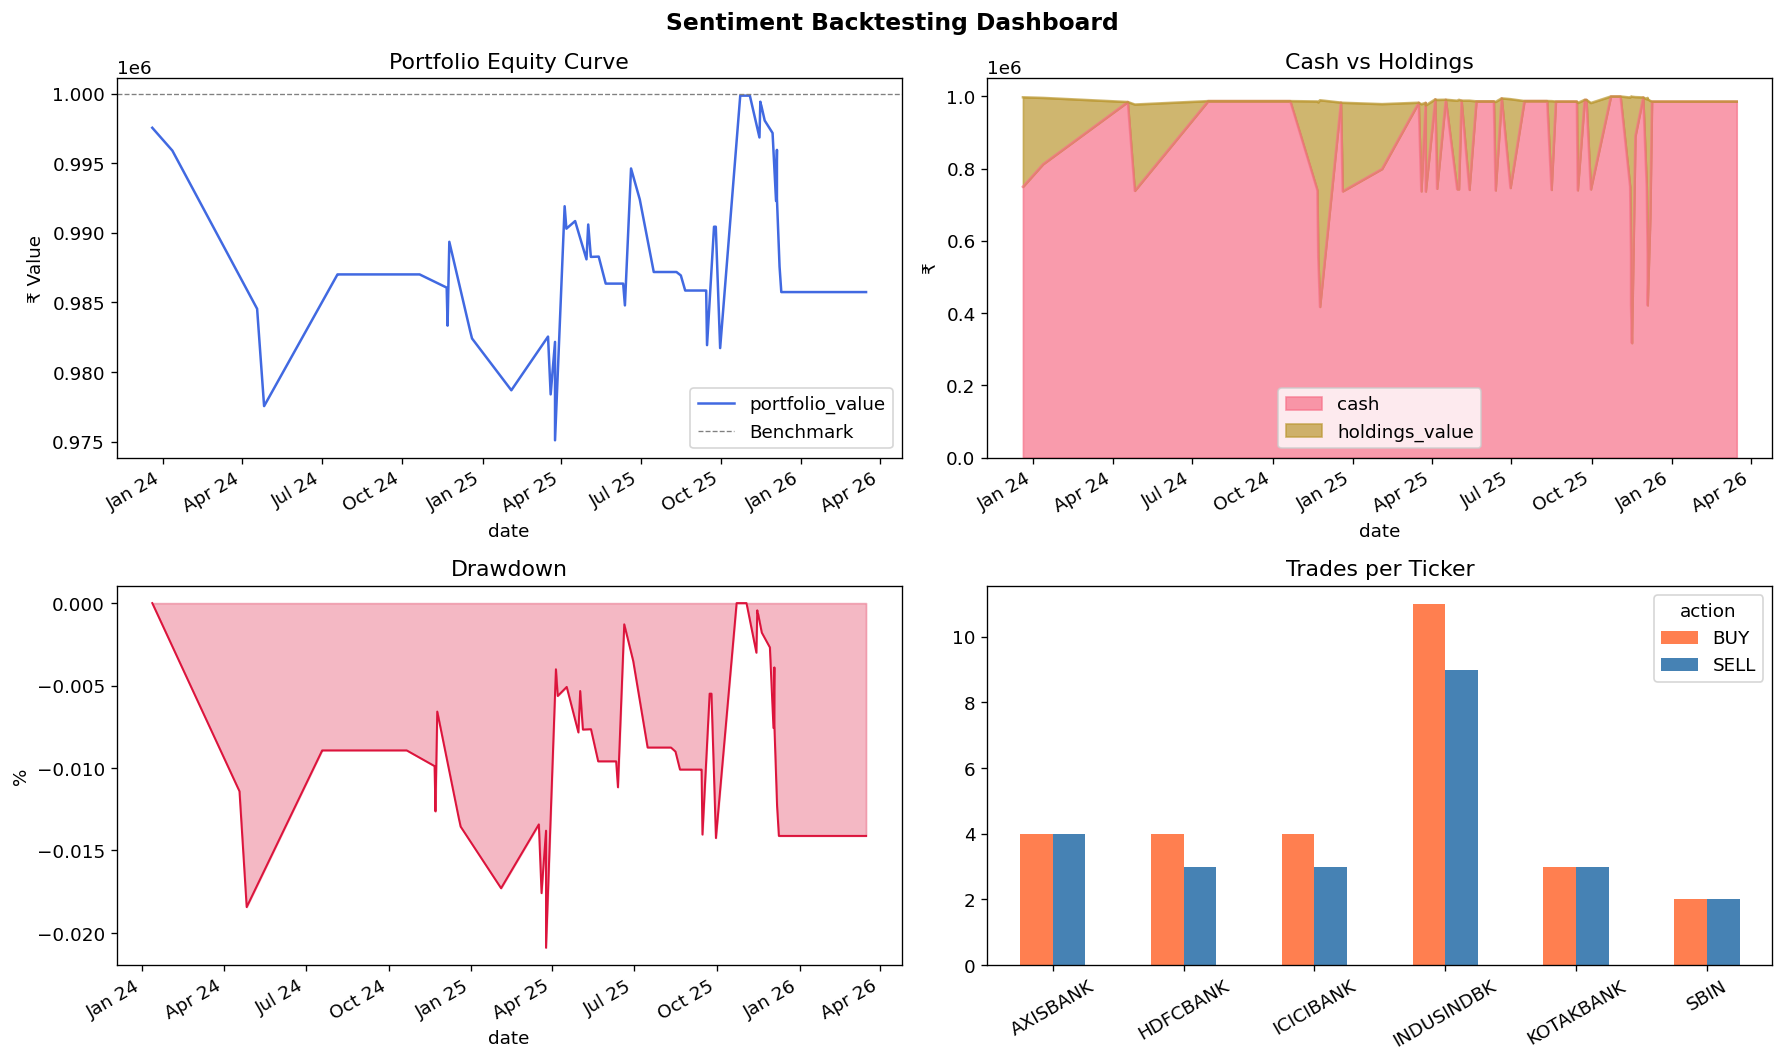

In [14]:
analyzer = BacktestAnalyzer(results, INITIAL_CAPITAL)
analyzer.print_report()
analyzer.plot_equity_curve()

## 7. Trade log & CSV export

In [ ]:
if results['trades']:
    trades_df = pd.DataFrame(results['trades'])
    display(trades_df.head(20))

    trades_df.to_csv(REPORTS / 'trades_log.csv', index=False)
    print(f'✅ Saved {len(trades_df)} trades → {REPORTS}/trades_log.csv')

    daily_df = pd.DataFrame(results['daily_values'])
    daily_df.to_csv(REPORTS / 'daily_portfolio_values.csv', index=False)
    print(f'✅ Saved daily values → {REPORTS}/daily_portfolio_values.csv')
else:
    print('⚠️  No trades executed. Try lowering CONFIDENCE_THRESHOLD.')

## 8. Parameter sensitivity sweep
How does performance change as we vary confidence threshold and holding period?

Backtesting:   0%|          | 0/500 [00:00<?, ?it/s]

Backtesting:   0%|          | 0/500 [00:00<?, ?it/s]

Backtesting:   0%|          | 0/500 [00:00<?, ?it/s]

Backtesting:   0%|          | 0/500 [00:00<?, ?it/s]

Backtesting:   0%|          | 0/500 [00:00<?, ?it/s]

...

Backtesting:   0%|          | 0/500 [00:00<?, ?it/s]

Backtesting:   0%|          | 0/500 [00:00<?, ?it/s]

Backtesting:   0%|          | 0/500 [00:00<?, ?it/s]

Backtesting:   0%|          | 0/500 [00:00<?, ?it/s]

Backtesting:   0%|          | 0/500 [00:00<?, ?it/s]

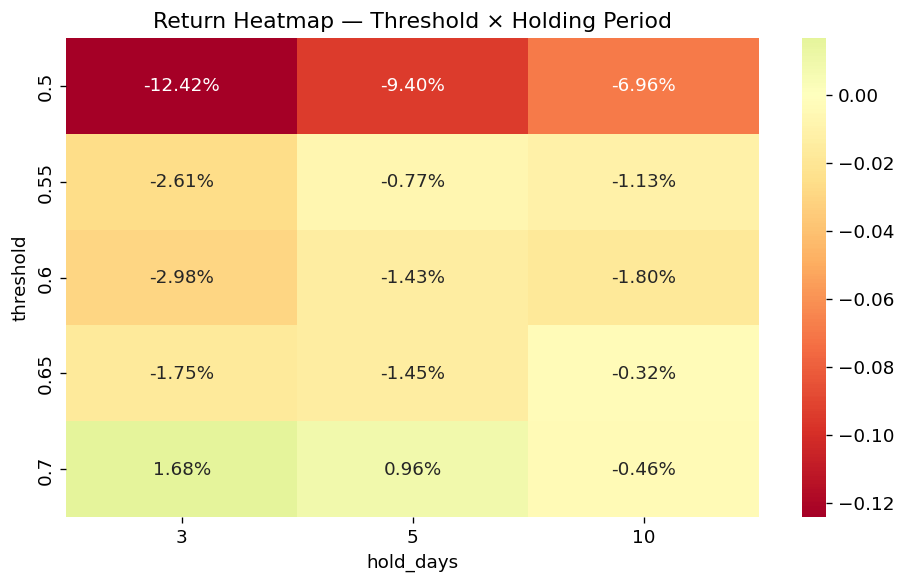

✅ Sweep saved


In [15]:
sweep_results = []
for threshold in [0.50, 0.55, 0.60, 0.65, 0.70]:
    for hold in [3, 5, 10]:
        _bt = SentimentBacktester(initial_capital=INITIAL_CAPITAL)
        _r  = _bt.run(news_data, predictions,
                      confidence_threshold=threshold, holding_period=hold)
        ret = (_r['final_portfolio_value'] - INITIAL_CAPITAL) / INITIAL_CAPITAL
        sweep_results.append({'threshold': threshold, 'hold_days': hold,
                               'total_return': ret, 'num_trades': _r['num_trades']})

sweep_df = pd.DataFrame(sweep_results)

pivot = sweep_df.pivot(index='threshold', columns='hold_days', values='total_return')
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.2%', cmap='RdYlGn', center=0, ax=ax)
ax.set_title('Return Heatmap — Threshold × Holding Period')
plt.tight_layout()
plt.savefig(PLOTS / 'parameter_sweep.png', dpi=130, bbox_inches='tight')
plt.show()

sweep_df.to_csv(REPORTS / 'parameter_sweep.csv', index=False)
print('✅ Sweep saved')